In [3]:
import matplotlib.pyplot as plt
import numpy as np

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)


# Analisis de datos

In [19]:
housing = strat_train_set.copy()

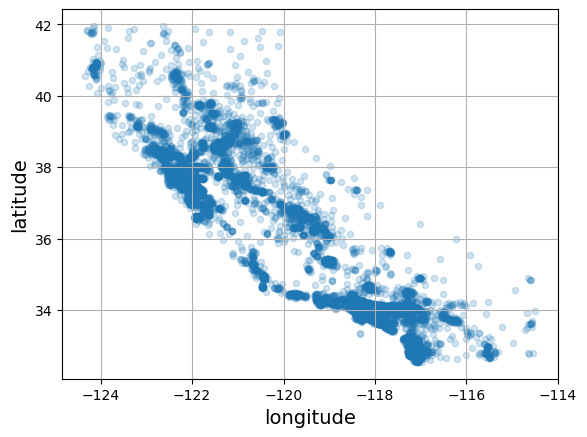

In [20]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

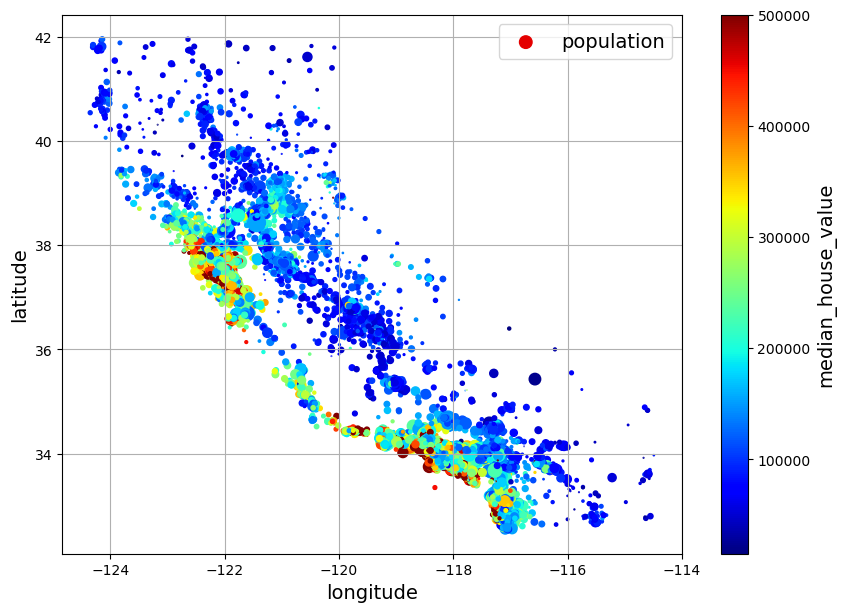

In [21]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
 s=housing["population"] / 100, label="population",
 c="median_house_value", cmap="jet", colorbar=True,
 legend=True, sharex=False, figsize=(10, 7))
plt.show()


In [22]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

# Visualizacion de correlacion

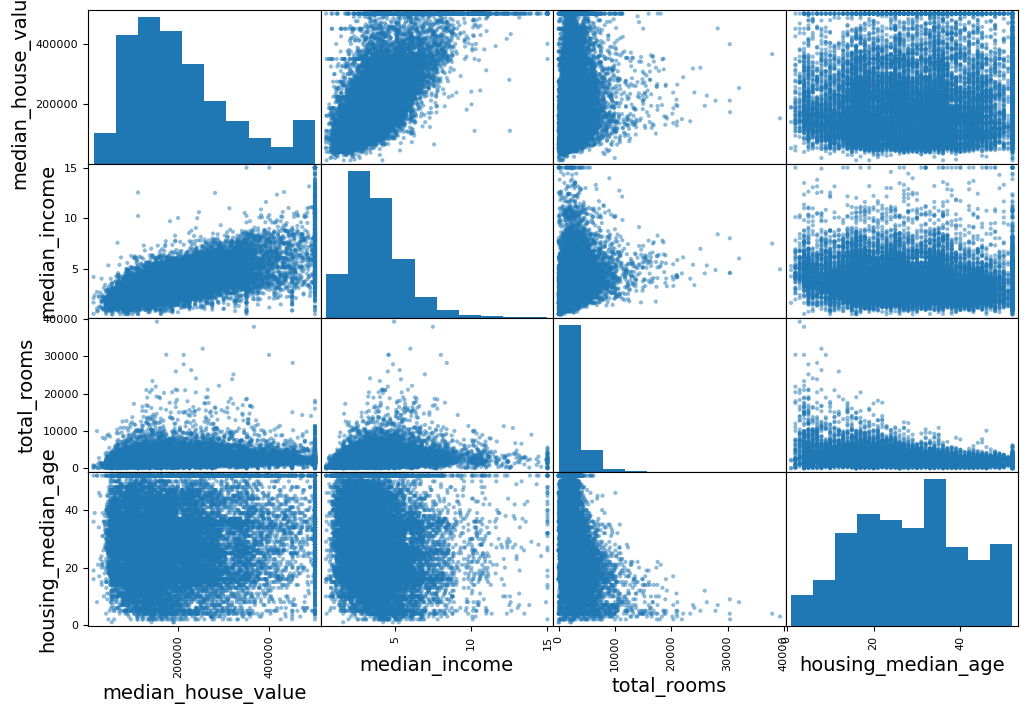

In [23]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
 "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

### Visualizacion del atributo mas prometedor

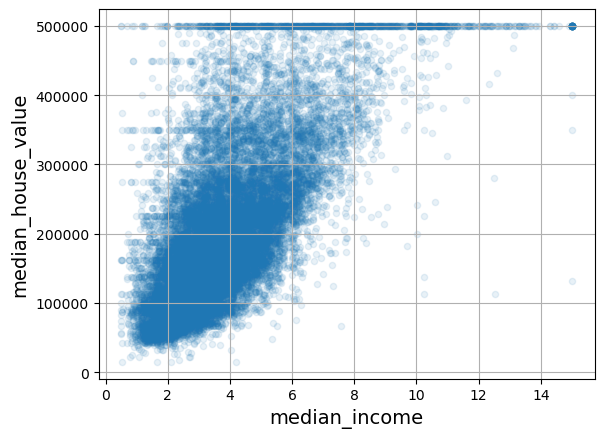

In [24]:
housing_full.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)
plt.show()

# Feuture enginnering

In [25]:
# Creamos los nuevos feuture
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [26]:
# Miramos las nuevas correlaciones
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

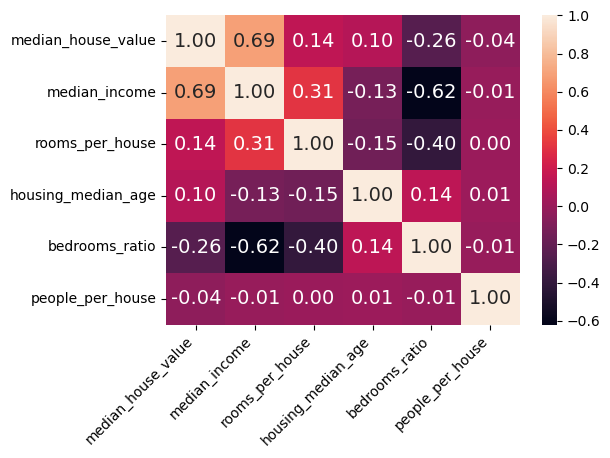

In [27]:
# Visualizamos la nuevas correlaciones
attributes_feauture = ["median_house_value", "median_income", "rooms_per_house",
 "housing_median_age", "bedrooms_ratio", "people_per_house"]

import seaborn as sns

corr = housing[attributes_feauture].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# *Preparacion de datos para ML*

In [28]:
housing = strat_train_set.drop("median_house_value", axis=1)
housin_labels = strat_train_set["median_house_value"].copy()

In [29]:
print(type(housin_labels))
print(type(housing))

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


In [30]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [31]:
# Excluir los atributos de 'str'

housing_num = housing.select_dtypes(include=[np.number])

In [32]:
# Ajustar fit a los datos de entrenamiento

imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [33]:
# Media de todos las columnas
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [34]:
# Transformacion de los datos
X = imputer.transform(housing_num)

In [35]:
type(X)

numpy.ndarray

In [36]:
housin_tr = pd.DataFrame(X, columns=housing_num.columns,
                        index=housing_num.index)

### Transformando variablers categoricas

In [37]:
# Variable categorica

housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [38]:
# Variables categoricas con ordinalencoder
#from sklearn.preprocessing import OrdinalEncoder

#ordinal_encoded = OrdinalEncoder()
#housin_cat_encoded = ordinal_encoded.fit_transform(housing_cat)


In [39]:
#housin_cat_encoded[:8]

In [40]:
#ordinal_encoded.categories_

In [41]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housin_1hot = cat_encoder.fit_transform(housing_cat)

In [42]:
print(type(housing_cat))
print(type(housin_1hot))

<class 'pandas.core.frame.DataFrame'>
<class 'scipy.sparse._csr.csr_matrix'>


In [43]:
housin_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [44]:
# Convertir a array

#housing_cat_1hot.toarray()

In [45]:
# Ver nombres de columnas al hacer la transformacion
#print(cat_encoder.feuture_names_in_)




### Normalizacion de datos 


In [46]:
# Normalizacion MinMax
#from sklearn.preprocessing import MinMaxScaler

#min_max_scaler = MinMaxScaler(feuture_range=(-1,1))
#housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [48]:
# Nomarmalizacion Standarescaler
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
houising_num_std_scaled = std_scaler.fit_transform(housing_num)

In [ ]:
# Transformar un feuture para que tenga una distribucion normal

#from sklearn.metrics.pairwise import rbf_kernel 
#age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

In [ ]:
# Escalamiento de la variable target
# inverse_transform para ver la predicción en escala original
"""
from sklearn.linear_model import LinearRegression 
target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())
model = LinearRegression() 
model.fit(housing[["median_income"]], scaled_labels) 
some_new_data = housing[["median_income"]].iloc[:5]  
# pretend this is new data 
scaled_predictions = model.predict(some_new_data) 
predictions = target_scaler.inverse_transform(scaled_predictions)
"""

In [ ]:
# Forma automatica para el escalamiento de la variable target y que devuelva el valor original

from sklearn.compose import TransformedTargetRegressor 
model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler()) 
model.fit(housing[["median_income"]], housing_labels) 
predictions = model.predict(some_new_data)

In [ ]:
# Transformar automaticamente un feuture para tener una ditribucion nomal

#from sklearn.preprocessing import FunctionTransformer
#log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)  #inverse_func es opcional

# Tambien se puede usar para el metodo rbf _kerrnel
#rbf_transformer = FunctionTransformer(rbf_kernel, 
#                                    kw_args=dict(Y=[[35.]],     
#                                    gamma=0.1)) 
#age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

In [ ]:
# =================================================================                     
# CREACIÓN DE TRANSFORMADOR PERSONALIZADO (CUSTOM TRANSFORMER)
# =================================================================
# Objetivo: Ir más allá de funciones simples y crear un componente 
# "entrenable" que aprenda de los datos antes de transformarlos.
#
# Características principales:
# 1. Herencia: 
#    - TransformerMixin: Nos da automáticamente el método .fit_transform().
#    - BaseEstimator: Permite que el transformador sea compatible con 
#      la búsqueda automática de hiperparámetros (Tuning).
#
# 2. Métodos Requeridos:
#    - fit(): Aprende parámetros (ej. promedios, centros de clusters).
#    - transform(): Aplica lo aprendido a los datos (entradas o nuevas).
#
# 3. Caso de uso: Encontrar las 10 regiones más caras en el set de 
#    entrenamiento y calcular qué tan cerca están los demás distritos
#    usando una medida de similitud (RBF).
# =================================================================

#from sklearn.vase import BaseEstimator, TransformerMicin
#from sklearn.utils.validation import check_array, check_is_fitted

#class StandardScalerClone(BaseEstimator, TransformerMixin):
#    def __init__(self, with_mean=True):
#        self.with_mean = with_mean
#        
#        def fit(self, X, y=None):
#            X = check_array(X)
#            self.scale_ = X.std(axis=0)
#            self.n_features_in_ = Xshape[1]

#            return self

#    def transform(self, X):
#        check_is_fitted(self)

#        X = check_array(X)
#        assert self.n_features_in_ == X.shape[1]
#        if self.with_mean:\
#            X = X - self.mean_
#        return X / self.scale_


In [ ]:
from sklearn.cluster import KMeans 
class ClusterSimilarity(BaseEstimator, TransformerMixin): 
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None): 
        self.n_clusters = n_clusters 
        self.gamma = gamma 
        self.random_state = random_state 
    
    def fit(self, X, y=None, sample_weight=None): 
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state) 
        self.kmeans_.fit(X, sample_weight=sample_weight) 
        return self  # always return self! 
    
    def transform(self, X): 
            return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma) 
            
    def get_feature_names_out(self, names=None): 
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [50]:
# Ejemplo de como se usa los pipelins y el columntransformer

# Activar el modo digrama de pipeline
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector

# Activamos el diagrama para visualizar el pipeline creado
set_config(display="diagram")

# Separamos los atributos numericos y los categoricos
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms", 
                "total_bedrooms", "population", "households", "median_income"] 
cat_attribs = ["ocean_proximity"]

# Pipeline para las variables numericas
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

# Pipeline para las variables categoricas
cat_pipeline = Pipelie([
    ("impute", SimpleImputer(strategy="most_frequient"))
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_attribs, cat_attribs)
])

# Para que los datos sean dinamicos se hace lo siguiente
num_attribs_make = make_column_selector(dtype_include=["int64", "float64"])
cat_attribs_make = make_column_selector(dtype_include=["object", "category"])

preprocessing_make = ColumnTransformer([
    ('num', num_pipeline, num_attribs_make)
    ('cat', cat_pipeline, cat_attribs_make)
])

### Creacion del pipeline

- **bedrooms / rooms_per_house / people_per_house (ratio_pipeline):** crea 3 features nuevas calculando proporciones entre columnas (ratios) para capturar relaciones más útiles que los valores crudos.

- **log (log_pipeline):** aplica transformación logarítmica a variables con “cola larga” para reducir sesgo, comprimir outliers y hacer la distribución más amigable para el modelo.

- **geo (cluster_simil):** convierte lat/long en features de similitud/distancia a clusters geográficos, para que el modelo entienda mejor “zonas” sin aprender geografía desde cero.

- **cat (cat_pipeline):** toma columnas categóricas (object), rellena faltantes y las convierte a número






























s con one-hot encoding.

- **remainder (default_num_pipeline):** al resto de columnas numéricas les aplica el preprocesamiento estándar (típicamente imputación + escalado con StandardScaler).

In [ ]:
# Toma 2 columnas (X[:,0] y X[:,1]) y devuelve el ratio col0/col1 (una sola columna)
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

# sklearn llama esta función para nombrar la(s) columna(s) de salida del FunctionTransformer
# (no la llamas tú). Aquí siempre devolvemos un solo nombre: "ratio".
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

# Pipeline para crear un ratio:
# 1) Imputa NaN con la mediana
# 2) Calcula el ratio (col0/col1) -> queda 1 columna
# 3) Estandariza (StandardScaler)
def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

# Pipeline para aplicar log a columnas (una a una) y luego escalar
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

# Transformador para features geográficas (lat/long) basado en clusters (definido en otro lado)
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

# Pipeline numérico por defecto: imputar + escalar
default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# Aplica diferentes transformaciones a diferentes columnas
preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),      # total_bedrooms/total_rooms -> 1 col
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),   # total_rooms/households -> 1 col
    ("people_per_house", ratio_pipeline(), ["population", "households"]),   # population/households -> 1 col
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
], remainder=default_num_pipeline)  # one column remaining: housing_median_age